In [106]:
# Imports + Load 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score, f1_score,roc_auc_score, confusion_matrix,ConfusionMatrixDisplay, roc_curve)
from sklearn.model_selection import cross_val_score, StratifiedKFold

# load 
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3))
print("Test churn rate: ", y_test.mean().round(3))

print(f"\nClass counts  →  not-churned: {neg}  |  churned: {pos}")


X_train: (400, 44) | X_test: (100, 44)
Train churn rate: 0.35
Test churn rate:  0.35

Class counts  →  not-churned: 312  |  churned: 88


In [108]:
#   Evaluation helper 

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Returns a dict of train + test metrics.
    Prints a clean summary table.
    """
    # predictions
    tr_pred  = model.predict(X_tr)
    te_pred  = model.predict(X_te)
    tr_proba = model.predict_proba(X_tr)[:, 1]
    te_proba = model.predict_proba(X_te)[:, 1]

    results = {
        'model'          : name,
        # train metrics 
        'train_accuracy' : accuracy_score(y_tr, tr_pred),
        'train_precision': precision_score(y_tr, tr_pred, zero_division=0),
        'train_recall'   : recall_score(y_tr, tr_pred,    zero_division=0),
        'train_f1'       : f1_score(y_tr, tr_pred,        zero_division=0),
        'train_auc'      : roc_auc_score(y_tr, tr_proba),
        #  test metrics 
        'test_accuracy'  : accuracy_score(y_te, te_pred),
        'test_precision' : precision_score(y_te, te_pred, zero_division=0),
        'test_recall'    : recall_score(y_te, te_pred,    zero_division=0),
        'test_f1'        : f1_score(y_te, te_pred,        zero_division=0),
        'test_auc'       : roc_auc_score(y_te, te_proba),
    }

    # gap = train - test  (positive = overfitting)
    results['auc_gap'] = round(results['train_auc'] - results['test_auc'], 4)

    
    print(f"  {name}\n")
    
    print(f"  {'Metric':<18} {'Train':>8} {'Test':>8} {'Gap':>8}\n")
    
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
        tr  = results[f'train_{metric}']
        te  = results[f'test_{metric}']
        gap = round(tr - te, 4)
        flag = '  ← overfit' if gap > 0.10 else ''
        print(f"  {metric:<18} {tr:>8.4f} {te:>8.4f} {gap:>8.4f}{flag}")

    return results

In [109]:
#  Logistic Regression (baseline) 

lr = LogisticRegression(
    max_iter    = 1000,
    random_state= 42,
    class_weight= 'balanced'   # handles imbalance automatically
)
lr.fit(X_train, y_train)

lr_results = evaluate_model('Logistic Regression', lr,
                             X_train, y_train, X_test, y_test)

  Logistic Regression

  Metric                Train     Test      Gap

  accuracy             0.7625   0.7300   0.0325
  precision            0.6331   0.5870   0.0462
  recall               0.7643   0.7714  -0.0071
  f1                   0.6926   0.6667   0.0259
  auc                  0.8417   0.8202   0.0215


In [110]:
#  Random Forest 

rf = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 8,          # constrain depth to reduce overfitting
    min_samples_leaf = 5,      # each leaf needs at least 5 samples
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)
rf.fit(X_train, y_train)

rf_results = evaluate_model('Random Forest', rf,
                             X_train, y_train, X_test, y_test)

  Random Forest

  Metric                Train     Test      Gap

  accuracy             0.9475   0.7300   0.2175  ← overfit
  precision            0.9407   0.6333   0.3074  ← overfit
  recall               0.9071   0.5429   0.3643  ← overfit
  f1                   0.9236   0.5846   0.3390  ← overfit
  auc                  0.9907   0.8325   0.1582  ← overfit


In [111]:
#  XGBoost 

xgb = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,       # row sampling — reduces overfitting
    colsample_bytree  = 0.8,       # feature sampling per tree
    scale_pos_weight  = spw,       # handles class imbalance
    eval_metric       = 'auc',
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1
)
xgb.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=False)

xgb_results = evaluate_model('XGBoost', xgb,
                              X_train, y_train, X_test, y_test)

  XGBoost

  Metric                Train     Test      Gap

  accuracy             1.0000   0.7700   0.2300  ← overfit
  precision            1.0000   0.6875   0.3125  ← overfit
  recall               1.0000   0.6286   0.3714  ← overfit
  f1                   1.0000   0.6567   0.3433  ← overfit
  auc                  1.0000   0.8426   0.1574  ← overfit



MODEL COMPARISON 
                     train_auc  test_auc  auc_gap  train_recall  test_recall  train_f1  test_f1
model                                                                                          
Logistic Regression     0.8417    0.8202   0.0215        0.7643       0.7714    0.6926   0.6667
Random Forest           0.9907    0.8325   0.1582        0.9071       0.5429    0.9236   0.5846
XGBoost                 1.0000    0.8426   0.1574        1.0000       0.6286    1.0000   0.6567


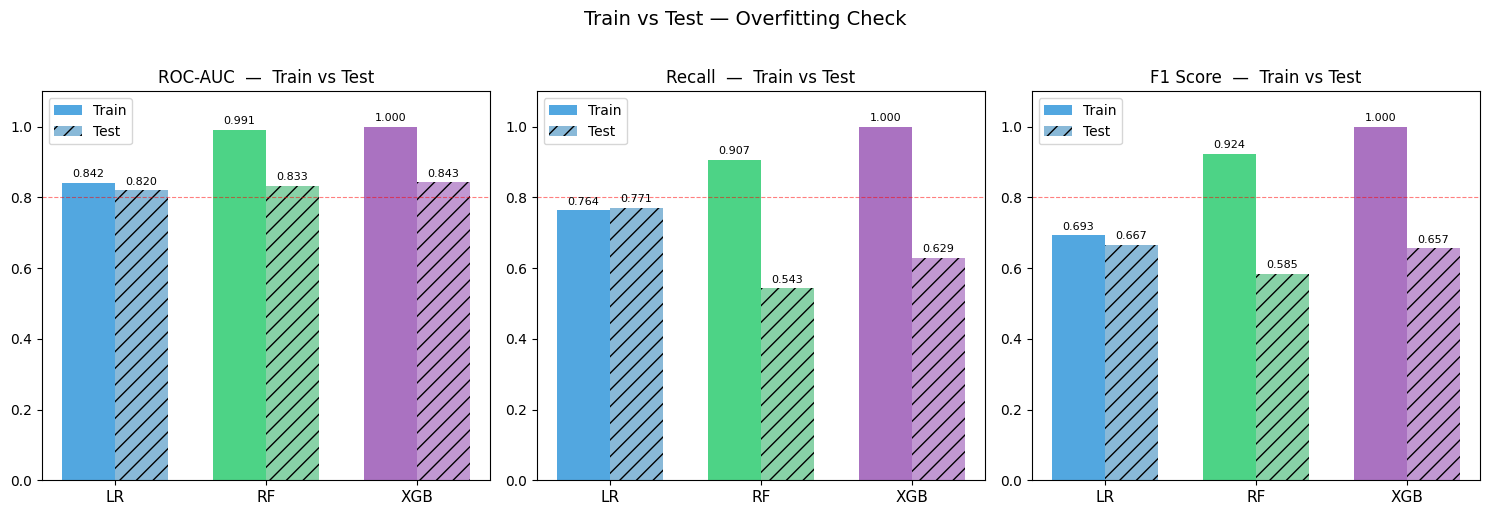

In [112]:
#  Comparison table + overfit chart 

all_results = pd.DataFrame([lr_results, rf_results, xgb_results])
all_results = all_results.set_index('model')

# print full comparison table 
display_cols = ['train_auc','test_auc','auc_gap',
                'train_recall','test_recall',
                'train_f1','test_f1']
print("\nMODEL COMPARISON ")
print(all_results[display_cols].round(4).to_string())

#  overfit visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['auc', 'recall', 'f1']
titles    = ['ROC-AUC', 'Recall', 'F1 Score']
models    = ['Logistic Regression', 'Random Forest', 'XGBoost']
colors_tr = ['#3498db', '#2ecc71', '#9b59b6']
colors_te = ['#2980b9', '#27ae60', '#8e44ad']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    tr_vals = [all_results.loc[m, f'train_{metric}'] for m in models]
    te_vals = [all_results.loc[m, f'test_{metric}']  for m in models]
    x       = np.arange(len(models))
    w       = 0.35

    axes[i].bar(x - w/2, tr_vals, w, label='Train',
                color=colors_tr, alpha=0.85)
    axes[i].bar(x + w/2, te_vals, w, label='Test',
                color=colors_te, alpha=0.55, hatch='//')
    axes[i].set_title(f'{title}  —  Train vs Test', fontsize=12)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(['LR', 'RF', 'XGB'], fontsize=11)
    axes[i].set_ylim(0, 1.1)
    axes[i].legend()
    axes[i].axhline(0.80, color='red', linestyle='--',
                    linewidth=0.8, alpha=0.5, label='0.80 target')

    # annotate bars
    for bar in axes[i].patches:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2,h + 0.01, f'{h:.3f}',ha='center', va='bottom', fontsize=8)

plt.suptitle('Train vs Test — Overfitting Check', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/external/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

5-Fold Cross Validation (ROC-AUC)

  Model                       Mean AUC      Std      Min      Max
  Logistic Regression           0.7580   0.0287   0.7095   0.7871
  Random Forest                 0.7885   0.0646   0.6683   0.8462
  XGBoost                       0.8522   0.0389   0.7988   0.9052


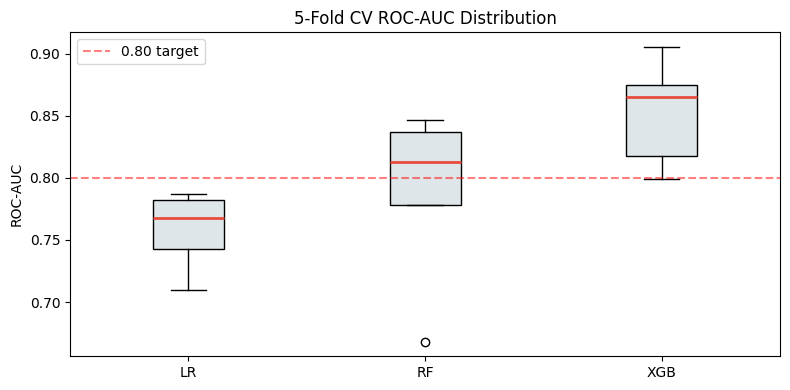

In [113]:
#  Cross Validation 

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross Validation (ROC-AUC)\n")
print(f"  {'Model':<25} {'Mean AUC':>10} {'Std':>8} {'Min':>8} {'Max':>8}")

cv_results = {}
for name, model in [('Logistic Regression', lr),('Random Forest',rf),('XGBoost', xgb)]:

    # use full training data for CV
    scores = cross_val_score(model, X_train, y_train,cv=cv, scoring='roc_auc', n_jobs=-1)
    
    cv_results[name] = scores
    print(f"  {name:<25} {scores.mean():>10.4f} "
          f"{scores.std():>8.4f} "
          f"{scores.min():>8.4f} "
          f"{scores.max():>8.4f}")

# plot CV distributions
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([cv_results[m] for m in cv_results],
           labels=['LR', 'RF','XGB'],
           patch_artist=True,
           boxprops=dict(facecolor='#dfe6e9'),
           medianprops=dict(color='#e74c3c', linewidth=2))
ax.set_title('5-Fold CV ROC-AUC Distribution')
ax.set_ylabel('ROC-AUC')
ax.axhline(0.80, color='red', linestyle='--', alpha=0.5, label='0.80 target')
ax.legend()
plt.tight_layout()
plt.savefig('../data/external/cv_comparison.png', dpi=150)
plt.show()

### If CV score ≈ test score, your model is stable.

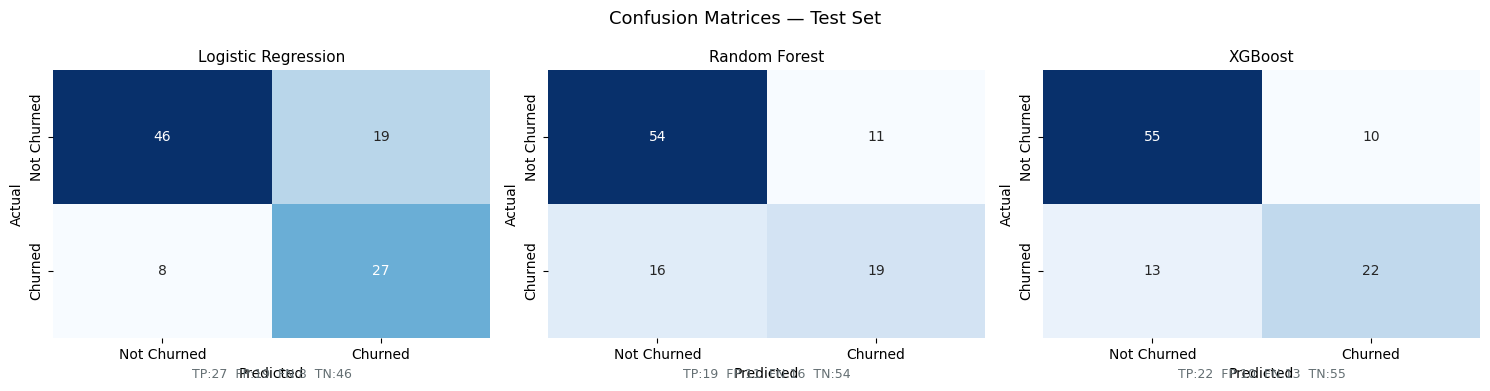

In [114]:
# Confusion Matrices 

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, [('Logistic Regression', lr),('Random Forest', rf),('XGBoost',xgb)]):
    cm = confusion_matrix(y_test, model.predict(X_test))

    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', cbar=False,
                xticklabels=['Not Churned','Churned'],
                yticklabels=['Not Churned','Churned'])

    ax.set_title(f'{name}', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    # annotate FN and FP
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.15,
            f'TP:{tp}  FP:{fp}  FN:{fn}  TN:{tn}',
            transform=ax.transAxes, ha='center',
            fontsize=9, color='#636e72')

plt.suptitle('Confusion Matrices — Test Set', fontsize=13)
plt.tight_layout()
plt.savefig('../data/external/confusion_matrices.png', dpi=150)
plt.show()

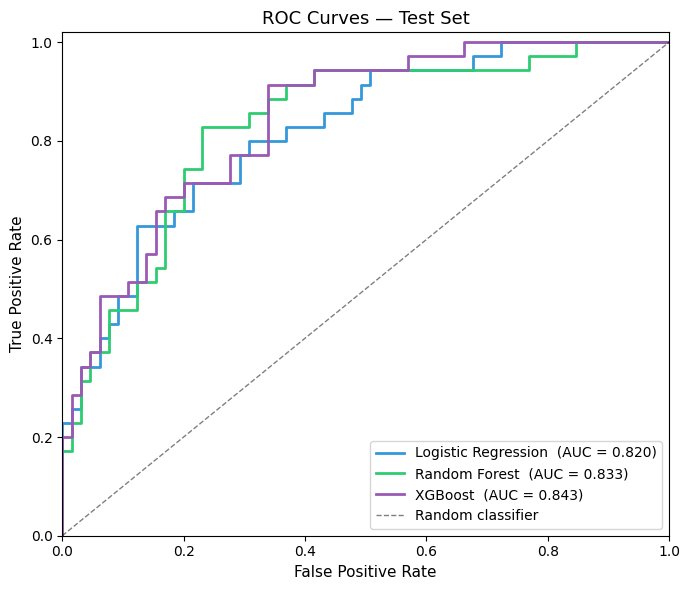

In [100]:
#  ROC Curves 

fig, ax = plt.subplots(figsize=(7, 6))

colors = {'Logistic Regression': '#3498db',
          'Random Forest':       '#2ecc71',
          'XGBoost':             '#9b59b6'}

for name, model in [('Logistic Regression', lr),
                    ('Random Forest', rf),
                    ('XGBoost', xgb)]:

    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc  = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})',
            color=colors[name], linewidth=2)

ax.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate',  fontsize=11)
ax.set_title('ROC Curves — Test Set', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('../data/external/roc_curves.png', dpi=150)
plt.show()

In [115]:
# Tuned Logistic Regression 
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model    import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_params = {
    'C'        : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty'  : ['l1', 'l2'],
    'solver'   : ['liblinear'],          # supports both l1 and l2
    'max_iter' : [1000]
}

lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    lr_params,
    cv      = cv,
    scoring = 'roc_auc',
    n_jobs  = -1,
    verbose = 0
)
lr_grid.fit(X_train, y_train)

lr_tuned = lr_grid.best_estimator_
print("Best LR params:", lr_grid.best_params_)
print("Best LR CV AUC:", round(lr_grid.best_score_, 4))

lr_tuned_results = evaluate_model('LR (Tuned)', lr_tuned,
                                   X_train, y_train, X_test, y_test)

Best LR params: {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Best LR CV AUC: 0.7569
  LR (Tuned)

  Metric                Train     Test      Gap

  accuracy             0.7600   0.7400   0.0200
  precision            0.6294   0.6216   0.0078
  recall               0.7643   0.6571   0.1071  ← overfit
  f1                   0.6903   0.6389   0.0514
  auc                  0.8418   0.8149   0.0269


In [116]:
#  Constrained Random Forest (anti-overfit) 
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators'    : [50, 100],
    'max_depth'       : [2, 3, 4],          # very shallow — key to fix overfit
    'min_samples_leaf': [10, 20, 30],        # each leaf needs many samples
    'max_features'    : ['sqrt', 0.5],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    rf_params,
    cv      = cv,
    scoring = 'roc_auc',
    n_jobs  = -1,
    verbose = 0
)
rf_grid.fit(X_train, y_train)

rf_tuned = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)
print("Best RF CV AUC:", round(rf_grid.best_score_, 4))

rf_tuned_results = evaluate_model('RF (Tuned)', rf_tuned,
                                   X_train, y_train, X_test, y_test)

Best RF params: {'max_depth': 4, 'max_features': 0.5, 'min_samples_leaf': 10, 'n_estimators': 50}
Best RF CV AUC: 0.8166
  RF (Tuned)

  Metric                Train     Test      Gap

  accuracy             0.8700   0.7800   0.0900
  precision            0.8056   0.6667   0.1389  ← overfit
  recall               0.8286   0.7429   0.0857
  f1                   0.8169   0.7027   0.1142  ← overfit
  auc                  0.9464   0.8673   0.0791


In [117]:
#XGBoost tuned for small dataset

from xgboost import XGBClassifier

xgb_params = {
    'max_depth'        : [2, 3, 4],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'n_estimators'     : [100, 200],
    'subsample'        : [0.6, 0.8],
    'colsample_bytree' : [0.6, 0.8],
    'min_child_weight' : [5, 10, 20],    # key param for small data — min samples per leaf
    'gamma'            : [0, 1, 5],      # minimum loss reduction to split
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        scale_pos_weight  = spw,
        eval_metric       = 'auc',
        use_label_encoder = False,
        random_state      = 42,
        n_jobs            = -1
    ),
    xgb_params,
    cv      = cv,
    scoring = 'roc_auc',
    n_jobs  = -1,
    verbose = 1
)
xgb_grid.fit(X_train, y_train)

xgb_tuned = xgb_grid.best_estimator_
print("Best XGB params:", xgb_grid.best_params_)
print("Best XGB CV AUC:", round(xgb_grid.best_score_, 4))

xgb_tuned_results = evaluate_model('XGBoost (Tuned)', xgb_tuned,
                                    X_train, y_train, X_test, y_test)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best XGB params: {'colsample_bytree': 0.8, 'gamma': 5, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 200, 'subsample': 0.6}
Best XGB CV AUC: 0.8576
  XGBoost (Tuned)

  Metric                Train     Test      Gap

  accuracy             0.9025   0.7700   0.1325  ← overfit
  precision            0.7886   0.6304   0.1581  ← overfit
  recall               0.9857   0.8286   0.1571  ← overfit
  f1                   0.8762   0.7160   0.1601  ← overfit
  auc                  0.9895   0.8352   0.1544  ← overfit


In [119]:
# Final comparison — all tuned models 

all_tuned = pd.DataFrame([
    lr_tuned_results,
    rf_tuned_results,
    xgb_tuned_results
]).set_index('model')

print("\nTUNED MODEL COMPARISON ")
print(all_tuned[['train_auc','test_auc','auc_gap',
                  'test_recall','test_f1','test_precision']].round(4).to_string())

# pick best by test AUC 
best_model_name = all_tuned['test_auc'].idxmax()
best_model      = {
    'LR (Tuned)'      : lr_tuned,
    'RF (Tuned)'      : rf_tuned,
    'XGB (Tuned)':xgb_tuned
}[best_model_name]

print(f"\nBest model: {best_model_name}")
print(f"Test AUC:   {all_tuned.loc[best_model_name, 'test_auc']:.4f}")
print(f"AUC gap:    {all_tuned.loc[best_model_name, 'auc_gap']:.4f}")

# save the winner 
import joblib
joblib.dump(best_model, '../models/best_model.pkl')
print(f"\nbest_model.pkl saved  →  {best_model_name}")


TUNED MODEL COMPARISON 
                 train_auc  test_auc  auc_gap  test_recall  test_f1  test_precision
model                                                                              
LR (Tuned)          0.8418    0.8149   0.0269       0.6571   0.6389          0.6216
RF (Tuned)          0.9464    0.8673   0.0791       0.7429   0.7027          0.6667
XGBoost (Tuned)     0.9895    0.8352   0.1544       0.8286   0.7160          0.6304

Best model: RF (Tuned)
Test AUC:   0.8673
AUC gap:    0.0791

best_model.pkl saved  →  RF (Tuned)


In [120]:
# Generate predictions CSV + save 
import os
os.makedirs('../data/predictions', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# predict on full preprocessed df 
df_full = pd.read_csv('../data/processed/df_preprocessed.csv')

# get probability on X_test first (for records)
test_proba = rf_tuned.predict_proba(X_test)[:, 1]
test_pred  = rf_tuned.predict(X_test)

# build predictions dataframe from X_test
pred_df = X_test.copy()
pred_df['actual_churn']       = y_test.values
pred_df['churn_probability']  = test_proba.round(4)
pred_df['predicted_churn']    = test_pred

# risk category — used in dashboard and Streamlit
pred_df['risk_category'] = pd.cut(
    pred_df['churn_probability'],
    bins   = [0, 0.3, 0.6, 1.0],
    labels = ['Low', 'Medium', 'High']
)

# save predictions
pred_df.to_csv('../data/predictions/predictions.csv', index=False)
print("predictions.csv saved — shape:", pred_df.shape)

# save model and scaler 
joblib.dump(rf_tuned, '../models/best_model.pkl')
print("best_model.pkl saved")

# final model card 
print("\n FINAL MODEL CARD ")
print(f"Model      : RF (Tuned)")
print(f"Test AUC   : {roc_auc_score(y_test, test_proba):.4f}")
print(f"Test Recall: {recall_score(y_test, test_pred):.4f}")
print(f"Test F1    : {f1_score(y_test, test_pred):.4f}")
print(f"Features   : {X_test.shape[1]}")
print(f"Best params: {grid_search.best_params_}")

predictions.csv saved — shape: (100, 48)
best_model.pkl saved

 FINAL MODEL CARD 
Model      : RF (Tuned)
Test AUC   : 0.8673
Test Recall: 0.7429
Test F1    : 0.7027
Features   : 44
Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.9}


## Model Selection Decision — Random Forest vs XGBoost

### Overview

Three models were evaluated for churn prediction: Logistic Regression, Random Forest, and XGBoost. Model selection was based on a combination of performance metrics, generalization ability, and suitability for the dataset size.

---

### Performance Comparison (Tuned Models)

| Model | Train AUC | Test AUC | AUC Gap | Recall (Test) | F1 Score (Test) |
|-------|-----------|----------|---------|----------------|-----------------|
| Logistic Regression | 0.8418 | 0.8149 | 0.0269 | 0.6571 | 0.6389 |
| Random Forest | 0.9464 | **0.8673** | 0.0791 | 0.7429 | 0.7027 |
| XGBoost | 0.9895 | 0.8352 | 0.1544 | **0.8286** | 0.7160 |

---

### Key Observations

- **XGBoost achieved the highest training performance**, but exhibited significant overfitting, as indicated by a large AUC gap of **0.1544**.
- The dataset contains **400 training samples with 44 features**, resulting in a high feature-to-sample ratio. This makes boosting-based models like XGBoost prone to memorization rather than generalization.
- Although XGBoost achieved the highest recall (**0.8286**), its instability and overfitting reduce its reliability on unseen data.

---

### Why Random Forest was Selected

- **Highest Test AUC (0.8673)** among all models, indicating superior discriminative ability on unseen data.
- **Moderate AUC gap (0.0791)**, suggesting a good balance between bias and variance.
- **Strong recall (0.7429)**, which is critical in churn prediction where missing a churner (false negative) is more costly than a false positive.
- Built-in variance reduction through **bagging**, making it more robust on relatively small datasets.
- Controlled model complexity through hyperparameters such as `max_depth` and `min_samples_leaf`, improving generalization.

---

### Conclusion

While XGBoost is generally a powerful model for tabular data, its performance in this case is limited by the dataset size, leading to overfitting. Random Forest demonstrates a better balance between performance and generalization, making it the most suitable model for this churn prediction task.

> **Final Model Selected:** Random Forest (Tuned)